In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
X_train, X_test, y_train, y_test = joblib.load('models/data_split_regression.pkl')
feature_cols = joblib.load('models/feature_cols.pkl')

# Load dataset asli untuk ambil info platform
df = pd.read_csv('data/hotel_reviews_dataset.csv')

print("✅ Data berhasil dimuat!")
print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test : {X_test.shape}")
print(f"\nFitur ({len(feature_cols)}):")
for col in feature_cols:
    print(f"   - {col}")

✅ Data berhasil dimuat!
Shape X_train: (3946, 12)
Shape X_test : (987, 12)

Fitur (12):
   - cleanliness
   - location
   - service
   - facility
   - value_for_money
   - is_facility_available
   - is_value_for_money_available
   - platform_Agoda
   - platform_Booking.com
   - platform_Tiket.com
   - platform_Traveloka
   - platform_Trip.com


In [2]:
# Identifikasi platform dari kolom one-hot di X_train
platform_cols = [col for col in feature_cols if col.startswith('platform_')]

def get_platform(row):
    for col in platform_cols:
        if row[col] == 1:
            return col.replace('platform_', '')
    return 'Unknown'

X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_df  = pd.DataFrame(X_test, columns=feature_cols)

train_platforms = X_train_df.apply(get_platform, axis=1)
test_platforms  = X_test_df.apply(get_platform, axis=1)

# Hitung weight per platform
# Weight = total_samples / (n_platforms * n_samples_platform)
platform_counts = train_platforms.value_counts()
n_platforms     = len(platform_counts)
n_total         = len(train_platforms)

platform_weights = {}
for platform, count in platform_counts.items():
    platform_weights[platform] = n_total / (n_platforms * count)

print("="*50)
print("SAMPLE WEIGHT PER PLATFORM")
print("="*50)
for platform, weight in sorted(platform_weights.items(), 
                                key=lambda x: x[1], reverse=True):
    count = platform_counts[platform]
    print(f"{platform:15s}: count={count:5d} ({count/n_total*100:.1f}%) "
          f"→ weight={weight:.4f}")

# Buat array sample weight untuk training
sample_weights = train_platforms.map(platform_weights).values

print(f"\n✅ Sample weights berhasil dihitung!")
print(f"   Min weight: {sample_weights.min():.4f}")
print(f"   Max weight: {sample_weights.max():.4f}")

SAMPLE WEIGHT PER PLATFORM
Booking.com    : count=  321 (8.1%) → weight=2.4586
Trip.com       : count=  416 (10.5%) → weight=1.8971
Traveloka      : count=  666 (16.9%) → weight=1.1850
Tiket.com      : count=  747 (18.9%) → weight=1.0565
Agoda          : count= 1796 (45.5%) → weight=0.4394

✅ Sample weights berhasil dihitung!
   Min weight: 0.4394
   Max weight: 2.4586


In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train   = r2_score(y_train, y_pred_train)
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test   = mean_absolute_error(y_test, y_pred_test)
    r2_test    = r2_score(y_test, y_pred_test)
    
    r2_gap = r2_train - r2_test
    overfit = f"⚠️ OVERFIT (gap={r2_gap:.4f})" if r2_gap > 0.1 else f"✅ Normal (gap={r2_gap:.4f})"
    
    return {
        'Model'      : model_name,
        'RMSE_Train' : round(rmse_train, 4),
        'RMSE_Test'  : round(rmse_test, 4),
        'MAE_Test'   : round(mae_test, 4),
        'R2_Train'   : round(r2_train, 4),
        'R2_Test'    : round(r2_test, 4),
        'Overfit'    : overfit
    }

def evaluate_per_platform(model, X_test, y_test, test_platforms, model_name):
    """Evaluasi model per platform"""
    results = []
    platforms = test_platforms.unique()
    
    for platform in sorted(platforms):
        mask = test_platforms == platform
        X_plat = X_test[mask]
        y_plat = y_test[mask]
        
        if len(y_plat) < 5:
            continue
            
        y_pred = model.predict(X_plat)
        rmse   = np.sqrt(mean_squared_error(y_plat, y_pred))
        mae    = mean_absolute_error(y_plat, y_pred)
        r2     = r2_score(y_plat, y_pred)
        
        results.append({
            'Platform' : platform,
            'N'        : len(y_plat),
            'RMSE'     : round(rmse, 4),
            'MAE'      : round(mae, 4),
            'R²'       : round(r2, 4)
        })
    
    df_result = pd.DataFrame(results)
    print(f"\n📊 {model_name} — Evaluasi Per Platform:")
    print(df_result.to_string(index=False))
    return df_result

all_results_weighted = {}
all_per_platform     = {}

print("✅ Setup evaluasi selesai!")

✅ Setup evaluasi selesai!


In [4]:
print("🌲 Training Random Forest (Weighted)...")

rf_w = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_w.fit(X_train, y_train, sample_weight=sample_weights)

rf_w_results = evaluate_model(
    rf_w, X_train, X_test, y_train, y_test,
    "Random Forest (Weighted)"
)
all_results_weighted['Random Forest'] = rf_w_results

rf_w_per_platform = evaluate_per_platform(
    rf_w, X_test, y_test, test_platforms,
    "Random Forest (Weighted)"
)
all_per_platform['Random Forest'] = rf_w_per_platform

joblib.dump(rf_w, 'models/rf_weighted_model.pkl')
print("\n✅ Model tersimpan: models/rf_weighted_model.pkl")

🌲 Training Random Forest (Weighted)...

📊 Random Forest (Weighted) — Evaluasi Per Platform:
   Platform   N   RMSE    MAE     R²
      Agoda 449 0.1460 0.1188 0.4907
Booking.com  80 0.1569 0.1304 0.4548
  Tiket.com 187 0.1771 0.1349 0.3809
  Traveloka 167 0.1719 0.1399 0.3976
   Trip.com 104 0.1732 0.1387 0.4726

✅ Model tersimpan: models/rf_weighted_model.pkl


In [5]:
print("⚡ Training XGBoost (Weighted)...")

# Load best params dari hasil tuning sebelumnya
xgb_best = joblib.load('models/xgb_model.pkl')
best_params = xgb_best.get_params()

xgb_w = XGBRegressor(
    **{k: v for k, v in best_params.items() 
       if k in ['n_estimators', 'max_depth', 'learning_rate',
                'subsample', 'colsample_bytree', 'min_child_weight',
                'reg_alpha', 'reg_lambda']},
    random_state=42,
    verbosity=0
)
xgb_w.fit(X_train, y_train, sample_weight=sample_weights)

xgb_w_results = evaluate_model(
    xgb_w, X_train, X_test, y_train, y_test,
    "XGBoost (Weighted)"
)
all_results_weighted['XGBoost'] = xgb_w_results

xgb_w_per_platform = evaluate_per_platform(
    xgb_w, X_test, y_test, test_platforms,
    "XGBoost (Weighted)"
)
all_per_platform['XGBoost'] = xgb_w_per_platform

joblib.dump(xgb_w, 'models/xgb_weighted_model.pkl')
print("\n✅ Model tersimpan: models/xgb_weighted_model.pkl")

⚡ Training XGBoost (Weighted)...

📊 XGBoost (Weighted) — Evaluasi Per Platform:
   Platform   N   RMSE    MAE     R²
      Agoda 449 0.1443 0.1180 0.5029
Booking.com  80 0.1567 0.1339 0.4563
  Tiket.com 187 0.1668 0.1288 0.4511
  Traveloka 167 0.1666 0.1328 0.4339
   Trip.com 104 0.1672 0.1347 0.5080

✅ Model tersimpan: models/xgb_weighted_model.pkl


In [6]:
print("🚀 Training LightGBM (Weighted)...")

lgbm_best = joblib.load('models/lgbm_model.pkl')
lgbm_best_params = lgbm_best.get_params()

lgbm_w = LGBMRegressor(
    **{k: v for k, v in lgbm_best_params.items()
       if k in ['n_estimators', 'num_leaves', 'max_depth',
                'learning_rate', 'min_child_samples',
                'feature_fraction', 'bagging_fraction',
                'bagging_freq', 'reg_alpha', 'reg_lambda']},
    random_state=42,
    verbose=-1
)
lgbm_w.fit(X_train, y_train, sample_weight=sample_weights)

lgbm_w_results = evaluate_model(
    lgbm_w, X_train, X_test, y_train, y_test,
    "LightGBM (Weighted)"
)
all_results_weighted['LightGBM'] = lgbm_w_results

lgbm_w_per_platform = evaluate_per_platform(
    lgbm_w, X_test, y_test, test_platforms,
    "LightGBM (Weighted)"
)
all_per_platform['LightGBM'] = lgbm_w_per_platform

joblib.dump(lgbm_w, 'models/lgbm_weighted_model.pkl')
print("\n✅ Model tersimpan: models/lgbm_weighted_model.pkl")

🚀 Training LightGBM (Weighted)...

📊 LightGBM (Weighted) — Evaluasi Per Platform:
   Platform   N   RMSE    MAE     R²
      Agoda 449 0.1436 0.1178 0.5075
Booking.com  80 0.1568 0.1343 0.4561
  Tiket.com 187 0.1680 0.1300 0.4431
  Traveloka 167 0.1675 0.1337 0.4278
   Trip.com 104 0.1673 0.1358 0.5079

✅ Model tersimpan: models/lgbm_weighted_model.pkl


In [7]:
print("📐 Training Ridge (Weighted)...")

ridge_best = joblib.load('models/ridge_model.pkl')

ridge_w = Ridge(alpha=ridge_best.alpha)
ridge_w.fit(X_train, y_train, sample_weight=sample_weights)

ridge_w_results = evaluate_model(
    ridge_w, X_train, X_test, y_train, y_test,
    "Ridge (Weighted)"
)
all_results_weighted['Ridge'] = ridge_w_results

ridge_w_per_platform = evaluate_per_platform(
    ridge_w, X_test, y_test, test_platforms,
    "Ridge (Weighted)"
)
all_per_platform['Ridge'] = ridge_w_per_platform

joblib.dump(ridge_w, 'models/ridge_weighted_model.pkl')
print("\n✅ Model tersimpan: models/ridge_weighted_model.pkl")

📐 Training Ridge (Weighted)...

📊 Ridge (Weighted) — Evaluasi Per Platform:
   Platform   N   RMSE    MAE     R²
      Agoda 449 0.1404 0.1148 0.5293
Booking.com  80 0.1496 0.1269 0.5047
  Tiket.com 187 0.1650 0.1279 0.4631
  Traveloka 167 0.1645 0.1316 0.4486
   Trip.com 104 0.1664 0.1329 0.5128

✅ Model tersimpan: models/ridge_weighted_model.pkl


In [8]:
print("🎯 Training SVR (Weighted)...")

svr_best = joblib.load('models/svr_model.pkl')

svr_w = SVR(
    kernel=svr_best.kernel,
    C=svr_best.C,
    epsilon=svr_best.epsilon,
    gamma=svr_best.gamma
)
svr_w.fit(X_train, y_train, sample_weight=sample_weights)

svr_w_results = evaluate_model(
    svr_w, X_train, X_test, y_train, y_test,
    "SVR (Weighted)"
)
all_results_weighted['SVR'] = svr_w_results

svr_w_per_platform = evaluate_per_platform(
    svr_w, X_test, y_test, test_platforms,
    "SVR (Weighted)"
)
all_per_platform['SVR'] = svr_w_per_platform

joblib.dump(svr_w, 'models/svr_weighted_model.pkl')
print("\n✅ Model tersimpan: models/svr_weighted_model.pkl")

🎯 Training SVR (Weighted)...

📊 SVR (Weighted) — Evaluasi Per Platform:
   Platform   N   RMSE    MAE     R²
      Agoda 449 0.1412 0.1155 0.5242
Booking.com  80 0.1565 0.1349 0.4581
  Tiket.com 187 0.1654 0.1269 0.4603
  Traveloka 167 0.1640 0.1311 0.4520
   Trip.com 104 0.1559 0.1241 0.5724

✅ Model tersimpan: models/svr_weighted_model.pkl


In [9]:
# Load hasil baseline dari 03
baseline_results = pd.read_csv('data/regression_results.csv')

# Buat tabel weighted
weighted_df = pd.DataFrame(all_results_weighted).T.reset_index(drop=True)
weighted_df = weighted_df.sort_values('R2_Test', ascending=False).reset_index(drop=True)
weighted_df.index += 1

print("="*75)
print("🏆 PERBANDINGAN BASELINE vs WEIGHTED")
print("="*75)

print("\n📊 Baseline (tanpa weighted):")
print(baseline_results[['Model', 'RMSE_Test', 'MAE_Test', 
                          'R2_Test', 'Overfit']].to_string(index=False))

print("\n📊 Weighted Training:")
print(weighted_df[['Model', 'RMSE_Test', 'MAE_Test', 
                    'R2_Test', 'Overfit']].to_string(index=False))

# Simpan hasil weighted
weighted_df.to_csv('data/weighted_results.csv', index=False)
print("\n✅ Hasil tersimpan: data/weighted_results.csv")


🏆 PERBANDINGAN BASELINE vs WEIGHTED

📊 Baseline (tanpa weighted):
                   Model  RMSE_Test  MAE_Test  R2_Test                 Overfit
             SVR (Tuned)     0.1400    0.1102   0.6564  ✅ Normal (gap=-0.0038)
Ridge Regression (Tuned)     0.1407    0.1106   0.6528  ✅ Normal (gap=-0.0115)
         XGBoost (Tuned)     0.1437    0.1133   0.6375   ✅ Normal (gap=0.0473)
        LightGBM (Tuned)     0.1442    0.1135   0.6351   ✅ Normal (gap=0.0639)
Random Forest (Baseline)     0.1472    0.1153   0.6198 ⚠️ OVERFIT (gap=0.3238)

📊 Weighted Training:
                   Model RMSE_Test MAE_Test R2_Test                 Overfit
          SVR (Weighted)    0.1528   0.1228  0.6275  ✅ Normal (gap=-0.0041)
        Ridge (Weighted)    0.1531    0.123   0.626  ✅ Normal (gap=-0.0134)
      XGBoost (Weighted)    0.1561   0.1256  0.6109   ✅ Normal (gap=0.0432)
     LightGBM (Weighted)    0.1563   0.1261  0.6102   ✅ Normal (gap=0.0606)
Random Forest (Weighted)    0.1606   0.1284  0.5882 ⚠️ OVE

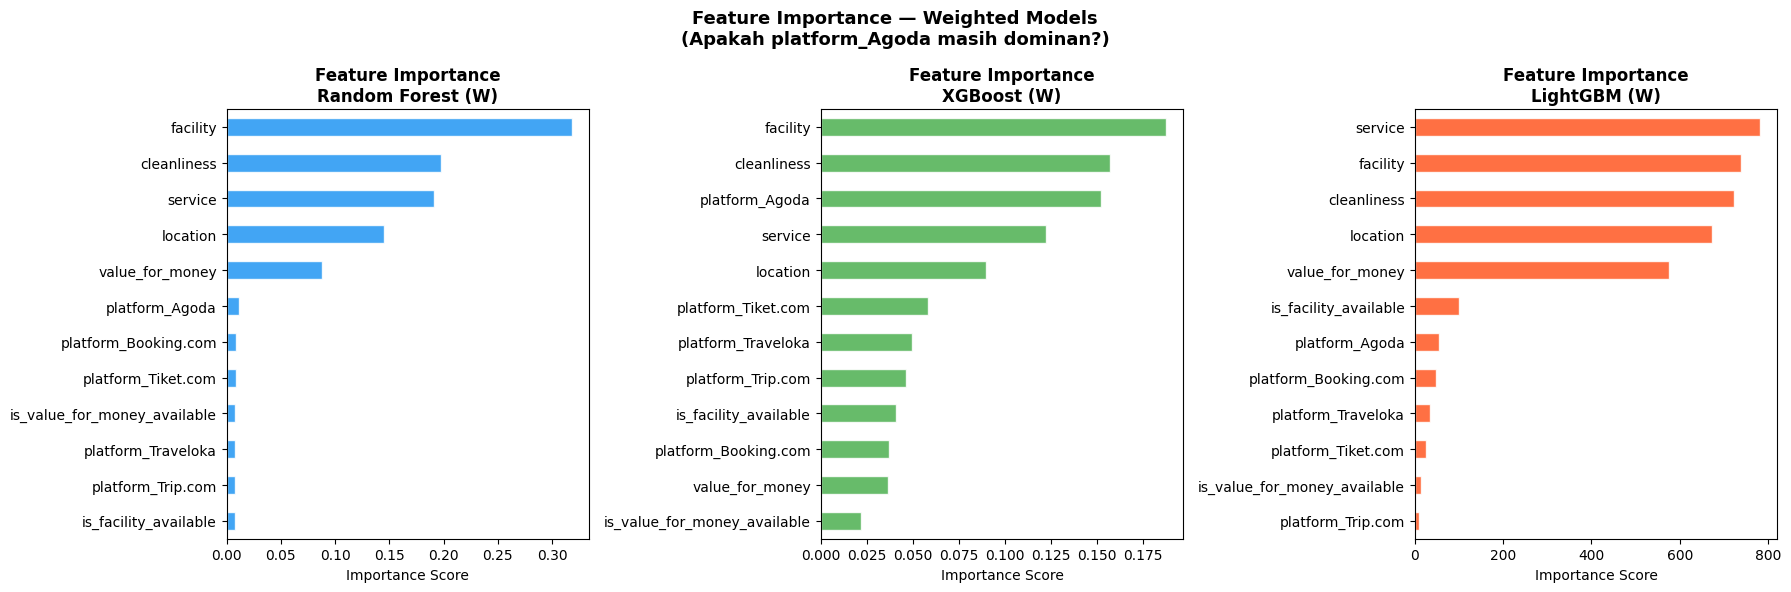

✅ Plot tersimpan: plots/weighted_feature_importance.png

📊 Feature Importance XGBoost Weighted:
   facility                           : 0.1876
   cleanliness                        : 0.1574
   platform_Agoda                     : 0.1521
   service                            : 0.1226
   location                           : 0.0900
   platform_Tiket.com                 : 0.0583
   platform_Traveloka                 : 0.0497
   platform_Trip.com                  : 0.0461
   is_facility_available              : 0.0409
   platform_Booking.com               : 0.0369
   value_for_money                    : 0.0364
   is_value_for_money_available       : 0.0220


In [10]:
import shap

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tree_models_w = {
    'Random Forest (W)' : rf_w,
    'XGBoost (W)'       : xgb_w,
    'LightGBM (W)'      : lgbm_w
}

colors = ['#2196F3', '#4CAF50', '#FF5722']

for i, (name, model) in enumerate(tree_models_w.items()):
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=True)
    
    feat_imp.plot(kind='barh', ax=axes[i], color=colors[i], 
                  alpha=0.85, edgecolor='white')
    axes[i].set_title(f'Feature Importance\n{name}', fontweight='bold')
    axes[i].set_xlabel('Importance Score')

plt.suptitle('Feature Importance — Weighted Models\n(Apakah platform_Agoda masih dominan?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/weighted_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot tersimpan: plots/weighted_feature_importance.png")

# Print ranking
print("\n📊 Feature Importance XGBoost Weighted:")
xgb_w_imp = pd.Series(xgb_w.feature_importances_, 
                       index=feature_cols).sort_values(ascending=False)
for feat, val in xgb_w_imp.items():
    print(f"   {feat:35s}: {val:.4f}")

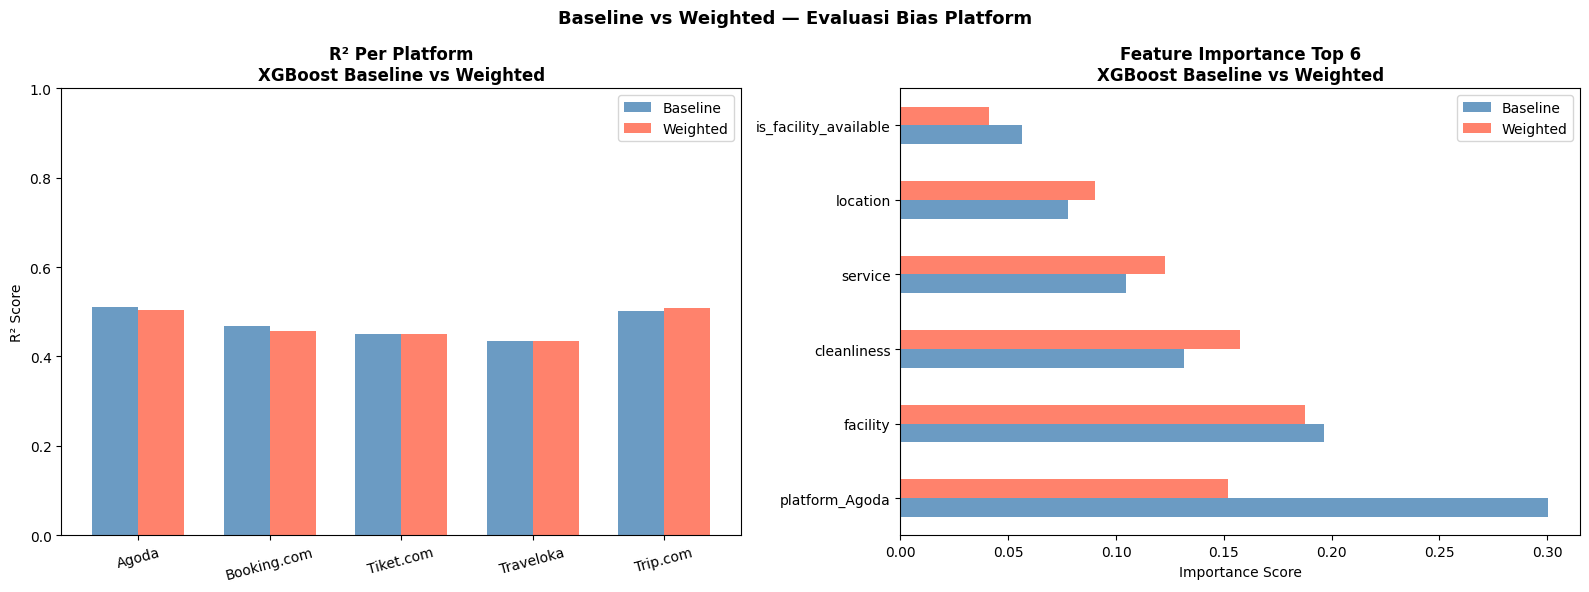

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kumpulkan R² per platform untuk XGBoost baseline vs weighted
# Load baseline model
xgb_baseline = joblib.load('models/xgb_model.pkl')

platforms_list = sorted(test_platforms.unique())
r2_baseline = []
r2_weighted = []

for platform in platforms_list:
    mask   = test_platforms == platform
    X_plat = X_test[mask]
    y_plat = y_test[mask]
    
    if len(y_plat) < 5:
        continue
    
    r2_baseline.append(r2_score(y_plat, xgb_baseline.predict(X_plat)))
    r2_weighted.append(r2_score(y_plat, xgb_w.predict(X_plat)))

x = np.arange(len(platforms_list))
width = 0.35

# Bar chart R² per platform
axes[0].bar(x - width/2, r2_baseline, width, 
            label='Baseline', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, r2_weighted, width,
            label='Weighted', color='tomato', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(platforms_list, rotation=15)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Per Platform\nXGBoost Baseline vs Weighted', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Feature importance comparison
xgb_base_imp = pd.Series(xgb_baseline.feature_importances_, 
                          index=feature_cols)
xgb_w_imp_s  = pd.Series(xgb_w.feature_importances_, 
                          index=feature_cols)

top_features = xgb_base_imp.nlargest(6).index
imp_compare  = pd.DataFrame({
    'Baseline' : xgb_base_imp[top_features],
    'Weighted' : xgb_w_imp_s[top_features]
})

imp_compare.plot(kind='barh', ax=axes[1], 
                 color=['steelblue', 'tomato'], alpha=0.8)
axes[1].set_title('Feature Importance Top 6\nXGBoost Baseline vs Weighted', 
                   fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Baseline vs Weighted — Evaluasi Bias Platform',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/baseline_vs_weighted_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print("="*60)
print("📋 KESIMPULAN WEIGHTED EXPERIMENT")
print("="*60)

# Cek apakah platform_Agoda masih dominan
xgb_w_imp_sorted = pd.Series(
    xgb_w.feature_importances_, 
    index=feature_cols
).sort_values(ascending=False)

top1_feature = xgb_w_imp_sorted.index[0]
top1_value   = xgb_w_imp_sorted.iloc[0]

print(f"\n🔍 Feature paling dominan setelah weighted:")
print(f"   {top1_feature}: {top1_value:.4f}")

if 'platform' in top1_feature:
    print(f"\n⚠️  Platform masih dominan setelah weighted!")
    print(f"   → Lanjut eksperimen tanpa platform (Model C)")
    bias_fixed = False
else:
    print(f"\n✅ Bias platform berhasil dikurangi!")
    print(f"   → Rating kategori kini lebih dominan")
    bias_fixed = True

# Bandingkan R² overall
xgb_base_r2 = float(baseline_results[
    baseline_results['Model'] == 'XGBoost (Tuned)'
]['R2_Test'].values[0])
xgb_w_r2 = float(weighted_df[
    weighted_df['Model'] == 'XGBoost (Weighted)'
]['R2_Test'].values[0])

print(f"\n📊 R² Comparison XGBoost:")
print(f"   Baseline : {xgb_base_r2:.4f}")
print(f"   Weighted : {xgb_w_r2:.4f}")
print(f"   Selisih  : {abs(xgb_w_r2 - xgb_base_r2):.4f}")

if not bias_fixed:
    print(f"\n➡️  REKOMENDASI: Lanjut ke eksperimen tanpa platform")
else:
    print(f"\n➡️  REKOMENDASI: Gunakan model weighted untuk website")

print("\n" + "="*60)

📋 KESIMPULAN WEIGHTED EXPERIMENT

🔍 Feature paling dominan setelah weighted:
   facility: 0.1876

✅ Bias platform berhasil dikurangi!
   → Rating kategori kini lebih dominan

📊 R² Comparison XGBoost:
   Baseline : 0.6375
   Weighted : 0.6109
   Selisih  : 0.0266

➡️  REKOMENDASI: Gunakan model weighted untuk website



In [13]:
# ── Benchmark: Rata-rata Sederhana vs XGBoost ───────────────
print("="*60)
print("BENCHMARK: RATA-RATA SEDERHANA vs XGBOOST WEIGHTED")
print("="*60)

# Load dataset asli (belum di-preprocess)
df_raw = pd.read_csv('data/hotel_reviews_dataset.csv')

# Ambil index test set
test_indices = X_test.index

# Kolom untuk rata-rata
rating_cols = ['cleanliness', 'location', 'service', 
               'facility', 'value_for_money']

# Hitung rata-rata sederhana untuk test set (skip NaN)
df_test = df_raw.loc[test_indices].copy()
y_pred_average = df_test[rating_cols].mean(axis=1)

# Evaluasi rata-rata sederhana
y_true = df_test['overall_score']

rmse_avg = np.sqrt(mean_squared_error(y_true, y_pred_average))
mae_avg  = mean_absolute_error(y_true, y_pred_average)
r2_avg   = r2_score(y_true, y_pred_average)

# Evaluasi XGBoost weighted
y_pred_xgb = xgb_w.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

# Tabel perbandingan
print(f"\n{'Metrik':10s} {'Rata-rata':>15s} {'XGBoost':>15s} {'Selisih':>15s}")
print("-"*60)
print(f"{'RMSE':10s} {rmse_avg:>15.4f} {rmse_xgb:>15.4f} {rmse_avg-rmse_xgb:>+15.4f}")
print(f"{'MAE':10s} {mae_avg:>15.4f} {mae_xgb:>15.4f} {mae_avg-mae_xgb:>+15.4f}")
print(f"{'R²':10s} {r2_avg:>15.4f} {r2_xgb:>15.4f} {r2_xgb-r2_avg:>+15.4f}")

print(f"\n💡 Kesimpulan:")
if r2_xgb > r2_avg:
    improvement = (r2_xgb - r2_avg) / abs(r2_avg) * 100 if r2_avg != 0 else 0
    print(f"   XGBoost Weighted LEBIH BAIK dari rata-rata sederhana!")
    print(f"   R² meningkat dari {r2_avg:.4f} → {r2_xgb:.4f}")
    print(f"   RMSE turun dari {rmse_avg:.4f} → {rmse_xgb:.4f}")
else:
    print(f"   ⚠️ Rata-rata sederhana ternyata lebih baik")
    print(f"   Perlu investigasi lebih lanjut")

BENCHMARK: RATA-RATA SEDERHANA vs XGBOOST WEIGHTED

Metrik           Rata-rata         XGBoost         Selisih
------------------------------------------------------------
RMSE                0.1559          0.1561         -0.0002
MAE                 0.1249          0.1256         -0.0007
R²                  0.6120          0.6109         -0.0011

💡 Kesimpulan:
   ⚠️ Rata-rata sederhana ternyata lebih baik
   Perlu investigasi lebih lanjut


In [14]:
import shap

# ── 1. Save XGBoost Weighted sebagai best model ──────────────
joblib.dump(xgb_w, 'models/best_regression_model.pkl')

# ── 2. Save Feature Importance ───────────────────────────────
feat_imp_w = pd.Series(
    xgb_w.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)
joblib.dump(feat_imp_w, 'models/xgb_feature_importance.pkl')

# ── 3. Hitung SHAP ───────────────────────────────────────────
print("⏳ Menghitung SHAP values XGBoost Weighted...")
explainer_xgb_w   = shap.TreeExplainer(xgb_w)
shap_values_xgb_w = explainer_xgb_w.shap_values(X_test)

joblib.dump(explainer_xgb_w,   'models/shap_explainer_xgb.pkl')
joblib.dump(shap_values_xgb_w, 'models/shap_values_xgb.pkl')

print("✅ Semua tersimpan!")
print("   models/best_regression_model.pkl → XGBoost Weighted")
print("   models/xgb_feature_importance.pkl")
print("   models/shap_explainer_xgb.pkl")
print("   models/shap_values_xgb.pkl")

⏳ Menghitung SHAP values XGBoost Weighted...
✅ Semua tersimpan!
   models/best_regression_model.pkl → XGBoost Weighted
   models/xgb_feature_importance.pkl
   models/shap_explainer_xgb.pkl
   models/shap_values_xgb.pkl
